In [1]:
import os
import torch
import torchaudio
import numpy as np
from torch.utils.data import DataLoader

from gtt.dataloader import GttDataset
from gtt.model import GttNet
from gtt.utilities.utils import train_test_split, get_mean_std_loudness

import IPython.display as ipd

2024-08-21 16:19:06.084975: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-21 16:19:06.127387: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-21 16:19:06.127458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-21 16:19:06.128529: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-21 16:19:06.135023: I tensorflow/core/platform/cpu_feature_guar

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Examples

## GuitarSet

In [3]:
gs_dir = 'Data/GuitarSet/audio_pickup'

split = train_test_split(gs_dir, train_pct=.8, valid_pct=.1)
train_files = split['train']
test_files = split['test']

loudness_metrics_gs = get_mean_std_loudness(gs_dir, train_files)


KeyboardInterrupt



### HRG

In [ ]:
gs_hrg_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = 'Data/GuitarSet/hr_labels',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             loud_mean = loudness_metrics_gs['mean'],
                             loud_std = loudness_metrics_gs['std'],
                             device=device)


gs_hrg_test_dl = DataLoader(gs_hrg_test_ds, 3, shuffle=False)

gs_hrg_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=False,
                      log_pitch=False,
                      use_reverb=False).to(device)


#load model
ckpt_path = 'model_checkpoints/guitarset_hrg/model_epoch_f.pt'

gs_hrg_model.load_state_dict(torch.load(ckpt_path))

gs_hrg_model.eval()

In [ ]:
for batch in gs_hrg_test_dl:
    in_audio = batch['audio'][0,...].cpu().numpy()
    
    out = gs_hrg_model(batch)
    out_audio = out[0,...].cpu().numpy()
    break
    
ipd.Display(ipd.Audio(in_audio, rate =22050))
ipd.Display(ipd.Audio(out_audio, rate =22050))


#torchaudio.save('guitarset_in.wav', in_audio, 22050)
#torchaudio.save('guitarset_reconstruct.wav', out_audio, 22050)

### BP

In [ ]:
gs_bp_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = '',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             loud_mean = loudness_metrics_gs['mean'],
                             loud_std = loudness_metrics_gs['std'],
                             device=device)


gs_bp_test_dl = DataLoader(gs_bp_test_ds, 3, shuffle=False)

gs_bp_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=False,
                      log_pitch=False,
                      use_reverb=False).to(device)


#load model
ckpt_path = 'model_checkpoints/guitarset_bp/model_epoch_f.pt'

gs_bp_model.load_state_dict(torch.load(ckpt_path))

gs_bp_model.eval()

In [ ]:
for batch in gs_bp_test_dl:
    in_audio = batch['audio'][0,...].cpu().numpy()
    
    out = gs_bp_model(batch)
    out_audio = out[0,...].cpu().numpy()
    break
    
ipd.Display(ipd.Audio(in_audio, rate =22050))
ipd.Display(ipd.Audio(out_audio, rate =22050))


#torchaudio.save('guitarset_in.wav', in_audio, 22050)
#torchaudio.save('guitarset_reconstruct.wav', out_audio, 22050)

### EGDB to GuitarSet

In [ ]:
gs_hrg_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = 'Data/GuitarSet/hr_labels',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             loud_mean = loudness_metrics_gs['mean'],
                             loud_std = loudness_metrics_gs['std'],
                             device=device)


gs_hrg_test_dl = DataLoader(gs_hrg_test_ds, 3, shuffle=False)

gs_hrg_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=False,
                      log_pitch=False,
                      use_reverb=False).to(device)


#load model
ckpt_path = 'model_checkpoints/guitarset_hrg/model_epoch_f.pt'

gs_hrg_model.load_state_dict(torch.load(ckpt_path))



In [ ]:
egdb_dir = 'Data/EGDB/audio'
egdb_baseline_dir = egdb_dir

gs_dir = 'Data/GuitarSet/audio_pickup'
gs_test_dir = 'Data/GuitarSet/test'

split = train_test_split(gs_dir, train_pct=.8, valid_pct=.1)

test_files = split['test']

egdb_bp_test_ds = GttDataset(audio_dir = egdb_dir,
                             midi_dir = '',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             trim_duration = 3,
                             loud_mean = loudness_metrics['mean'],
                             loud_std = loudness_metrics['std'],
                             device=device)
egdb_bp_test_dl = DataLoader(egdb_bp_test_ds, 3, shuffle=False)

gs_hrg_model.eval()
for batch in egdb_bp_test_dl:
    in_audio = batch['audio'][0,...].cpu().numpy()
    
    out = gs_hrg_model(batch)
    out_audio = out[0,...].cpu().numpy()
    break
    
ipd.Display(ipd.Audio(in_audio, rate =22050))
ipd.Display(ipd.Audio(out_audio, rate =22050))

#torchaudio.save('guitarset_in.wav', in_audio, 22050)
#torchaudio.save('guitarset_reconstruct.wav', out_audio, 22050)

## EGDB

In [ ]:
egdb_dir = 'Data/EGDB/audio'

split = train_test_split(egdb_dir, train_pct=.8, valid_pct=.1)

train_files = split['train']
test_files = split['test']

loudness_metrics = get_mean_std_loudness(egdb_dir, train_files)

egdb_bp_test_ds = GttDataset(audio_dir = egdb_dir,
                             midi_dir = '',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             trim_duration = 3,
                             loud_mean = loudness_metrics['mean'],
                             loud_std = loudness_metrics['std'],
                             device=device)

egdb_bp_test_dl = DataLoader(egdb_bp_test_ds, 3, shuffle=False)

ckpt_path = 'model_checkpoints/egdb_bp/model_epoch_f.pt'

egdb_bp_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=True,
                      log_pitch=False,
                      use_reverb=False).to(device)

egdb_bp_model.load_state_dict(torch.load(ckpt_path))

In [ ]:
for batch in gs_hrg_test_dl:
    in_audio = batch['audio'][0,...].cpu().numpy()
    
    out = egdb_bp_model(batch)
    out_audio = out[0,...].cpu().numpy()
    break
    
ipd.Display(ipd.Audio(in_audio, rate =22050))
ipd.Display(ipd.Audio(out_audio, rate =22050))


#torchaudio.save('guitarset_in.wav', in_audio, 22050)
#torchaudio.save('guitarset_reconstruct.wav', out_audio, 22050)

### GuitarSet BP to EGDB

In [ ]:
egdb_dir = 'Data/EGDB/audio'

gs_dir = 'Data/GuitarSet/audio_pickup'

split = train_test_split(gs_dir, train_pct=.8, valid_pct=.1)

test_files = split['test']

gs_bp_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = '',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             trim_duration = 3,
                             loud_mean = loudness_metrics['mean'],
                             loud_std = loudness_metrics['std'],
                             device=device)

gs_bp_test_dl = DataLoader(gs_bp_test_ds, 3, shuffle=False)



egdb_bp_model.eval()

for batch in gs_bp_test_dl:
    in_audio = batch['audio'][0,...].cpu().numpy()
    
    out = egdb_bp_model(batch)
    out_audio = out[0,...].cpu().numpy()
    break
    
ipd.Display(ipd.Audio(in_audio, rate =22050))
ipd.Display(ipd.Audio(out_audio, rate =22050))

#torchaudio.save('guitarset_in.wav', in_audio, 22050)
#torchaudio.save('guitarset_reconstruct.wav', out_audio, 22050)

### Guitarset HRG to EGDB

In [ ]:
egdb_dir = 'Data/EGDB/audio'

gs_dir = 'Data/GuitarSet/audio_pickup'

split = train_test_split(gs_dir, train_pct=.8, valid_pct=.1)

test_files = split['test']

gs_bp_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = 'Data/GuitarSet/hr_labels',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_pitch_classes=30,
                             random_crop=False,
                             trim_duration = 3,
                             loud_mean = loudness_metrics['mean'],
                             loud_std = loudness_metrics['std'],
                             device=device)

gs_bp_test_dl = DataLoader(gs_bp_test_ds, 3, shuffle=False)



egdb_bp_model.eval()

for batch in gs_bp_test_dl:
    in_audio = batch['audio'][0,...].cpu().numpy()
    
    out = egdb_bp_model(batch)
    out_audio = out[0,...].cpu().numpy()
    break
    
ipd.Display(ipd.Audio(in_audio, rate =22050))
ipd.Display(ipd.Audio(out_audio, rate =22050))

#torchaudio.save('guitarset_in.wav', in_audio, 22050)
#torchaudio.save('guitarset_reconstruct.wav', out_audio, 22050)

# Spectrograms

## GuitarSet Reconstruction

In [3]:
from gtt.utilities.utils import spec_plot
from matplotlib import pyplot as plt
import librosa

In [4]:
gs_dir = 'Data/GuitarSet/audio_pickup'

split = train_test_split(gs_dir, train_pct=.8, valid_pct=.1)
train_files = split['train']
test_files = split['test']

loudness_metrics_gs = get_mean_std_loudness(gs_dir, train_files)

gs_hrg_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = 'Data/GuitarSet/hr_labels',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_n_pitch=30,
                             random_crop=False,
                             loud_mean = loudness_metrics_gs['mean'],
                             loud_std = loudness_metrics_gs['std'],
                             full_amps = True,
                             device='cpu')

gs_hrg_test_dl= DataLoader(gs_hrg_test_ds, 3, shuffle=False)

gs_hrg_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=False,
                      gru_cat=False,
                      use_reverb=False).to(device)


#load model
ckpt_path = 'model_checkpoints/guitarset_hrg/model_epoch_final_config2.pt'

gs_hrg_model.load_state_dict(torch.load(ckpt_path))

gs_hrg_model = gs_hrg_model.eval()

In [5]:
for i, batch in enumerate(gs_hrg_test_dl):
    in_audio = batch['audio'][1,...].cpu()
    
    out_audio = gs_hrg_model(batch)[1,...].detach().cpu()
    
    if i == 1:
        break
print(in_audio.shape)
print(out_audio.shape)

torchaudio.save('guitarset_in.wav', in_audio.unsqueeze(0), 22050)
torchaudio.save('guitarset_reconstruct.wav', out_audio.unsqueeze(0), 22050)

ipd.display(ipd.Audio(in_audio.numpy(), rate =22050))
ipd.display(ipd.Audio(out_audio.numpy(), rate =22050))

in_audio = in_audio.numpy()

out_audio = out_audio.numpy()

/home/jovyan/Projects_Directory/Thesis/PolyDDSP/modules/operations.py:124: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  output_signal = nn.functional.conv_transpose1d(


torch.Size([88200])
torch.Size([88200])


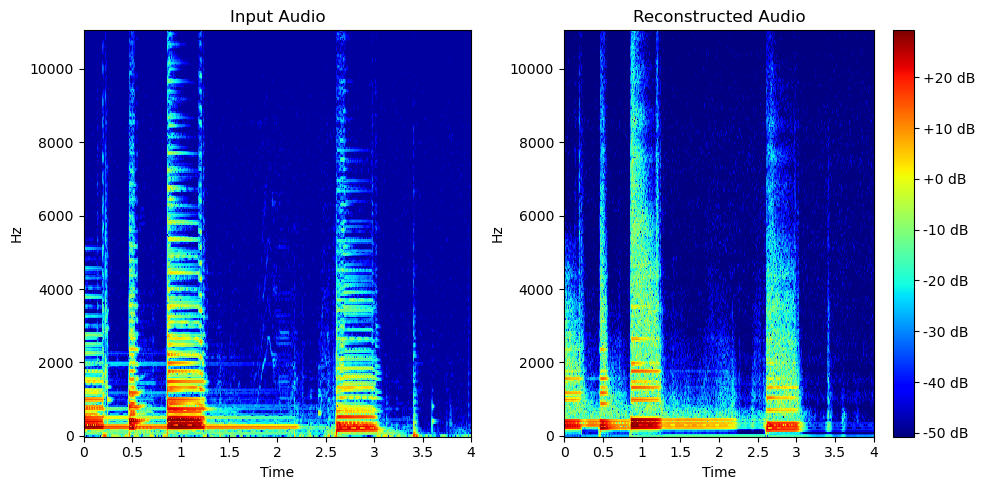

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#calc spects first to align axes
X_1 = librosa.stft(in_audio, n_fft=512, hop_length=128)
S_1 = librosa.amplitude_to_db(abs(X_1)) 

X_2 = librosa.stft(out_audio, n_fft=512, hop_length=128)
S_2 = librosa.amplitude_to_db(abs(X_2))

min_1 = S_1.min()
min_2 = S_2.min()

max_1 = S_1.max()
max_2 = S_2.max()

vmin = min_1 if min_1 < min_2 else min_2
vmax = max_1 if max_1 < max_2 else max_2


#input audio spect

v1 = librosa.display.specshow(S_1, 
                              sr=22050, 
                              hop_length=128, 
                              x_axis='time', 
                              y_axis='linear', 
                              cmap='jet', 
                              ax = axes[0],
                             vmin=vmin,
                             vmax=vmax)
#fig.colorbar(v1, format='%+2.0f dB', ax= axes[0])
axes[0].set_title('Input Audio')


#output audio spect

v1 = librosa.display.specshow(S_2, 
                              sr=22050, 
                              hop_length=128, 
                              x_axis='time', 
                              y_axis='linear', 
                              cmap='jet', 
                              ax=axes[1],
                             vmin=vmin,
                             vmax=vmax)
axes[1].set_title('Reconstructed Audio')
fig.colorbar(v1, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('reconstruction_figure.png', dpi=300)
plt.show()

## FAD Examples: Target EGDB

In [7]:
egdb_dir = 'Data/EGDB/audio'
st_dir = 'Data/synthtab_acoustic/audio'

egdb_split = train_test_split(egdb_dir, train_pct=.8, valid_pct=.1)

egdb_train_files = egdb_split['train']
egdb_test_files = egdb_split['test']


#get egdb loudness metrics used to normalize during training
loudness_metrics = get_mean_std_loudness(egdb_dir, egdb_train_files)

#get split used to calc fad
st_split = train_test_split(st_dir, train_pct=.8, valid_pct=.1)

st_test_files = st_split['test']

st_test_ds = GttDataset(audio_dir = st_dir,
                             midi_dir = '',
                             file_list = st_test_files, 
                             segment_length_seconds=4,
                             max_n_pitch=30,
                             random_crop=False,
                             permute_pitch=False,
                             trim_duration = 3,
                             loud_mean = loudness_metrics['mean'],
                             loud_std = loudness_metrics['std'],
                             device=device)

st_test_dl = DataLoader(st_test_ds, 3, shuffle=False)


#load models
egdb_bp_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=True,
                      gru_cat=False,
                      trainable_velocity=True,
                      use_reverb=False).to(device)


egdb_midi_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=False,
                      gru_cat=False,
                      use_reverb=False).to(device)


#load model
bp_ckpt_path = 'model_checkpoints/egdb_bp/model_epoch_final_config2.pt'
midi_ckpt_path = 'model_checkpoints/egdb_midi/model_epoch_final_config2.pt'

egdb_bp_model.load_state_dict(torch.load(bp_ckpt_path))
egdb_midi_model.load_state_dict(torch.load(midi_ckpt_path))

egdb_bp_model = egdb_bp_model.eval()
egdb_midi_model = egdb_midi_model.eval()

2024-08-21 16:21:58.129314: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
for i, batch in enumerate(st_test_dl):
    in_audio = batch['audio'][0,...].cpu()
    
    out_audio_bp = egdb_bp_model(batch)[0,...].detach().cpu()
    out_audio_midi = egdb_midi_model(batch)[0,...].detach().cpu()
    pitch_amplitudes = batch['amplitude'][0,...]

torchaudio.save('st_in.wav', in_audio.unsqueeze(0), 22050)
torchaudio.save('egdb_bp_out.wav', out_audio_bp.unsqueeze(0), 22050)
torchaudio.save('egdb_midi_out.wav', out_audio_midi.unsqueeze(0), 22050)

ipd.display(ipd.Audio(in_audio.numpy(), rate =22050))
ipd.display(ipd.Audio(out_audio_bp.numpy(), rate =22050))
ipd.display(ipd.Audio(out_audio_midi.numpy(), rate =22050))

in_audio = in_audio.numpy()

out_audio_bp = out_audio_bp.numpy()
out_audio_midi = out_audio_midi.numpy()

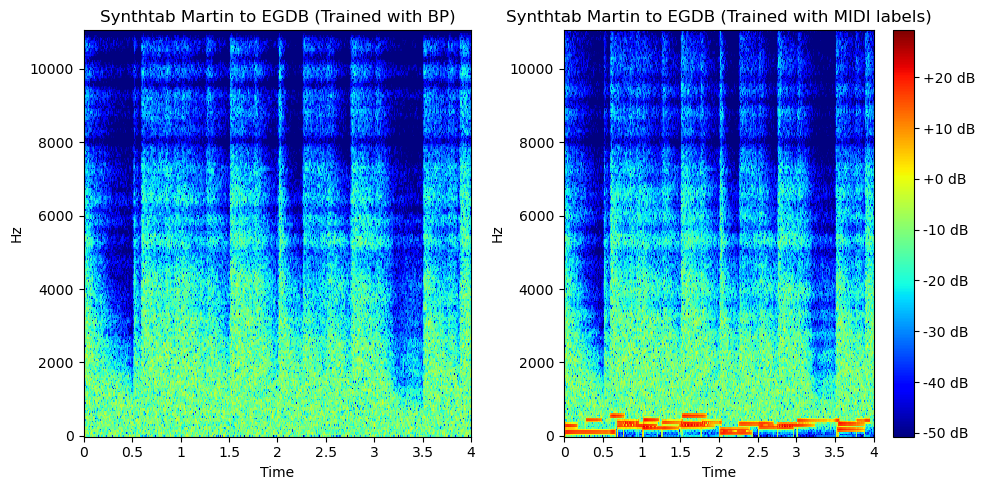

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#calc scale for colorbars
X_1 = librosa.stft(out_audio_bp, n_fft=512, hop_length=128)
S_1 = librosa.amplitude_to_db(abs(X_1)) 

X_2 = librosa.stft(out_audio_midi, n_fft=512, hop_length=128)
S_2 = librosa.amplitude_to_db(abs(X_2))

# min_1 = S_1.min()
# min_2 = S_2.min()

# max_1 = S_1.max()
# max_2 = S_2.max()

# vmin = min_1 if min_1 < min_2 else min_2
# vmax = max_1 if max_1 < max_2 else max_2


#input audio spect

v1 = librosa.display.specshow(S_1, 
                              sr=22050, 
                              hop_length=128, 
                              x_axis='time', 
                              y_axis='linear', 
                              cmap='jet',
                              vmin = vmin,
                              vmax = vmax,
                              ax = axes[0])
#fig.colorbar(v1, format='%+2.0f dB', ax= axes[0])
axes[0].set_title('Synthtab Martin to EGDB (Trained with BP)')

#output audio spect

v2 = librosa.display.specshow(S_2, 
                              sr=22050, 
                              hop_length=128, 
                              x_axis='time', 
                              y_axis='linear', 
                              cmap='jet',
                              vmin = vmin,
                              vmax = vmax,
                              ax=axes[1])
axes[1].set_title('Synthtab Martin to EGDB (Trained with MIDI labels)')
fig.colorbar(v2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('fad_figure.png', dpi=300)
plt.show()

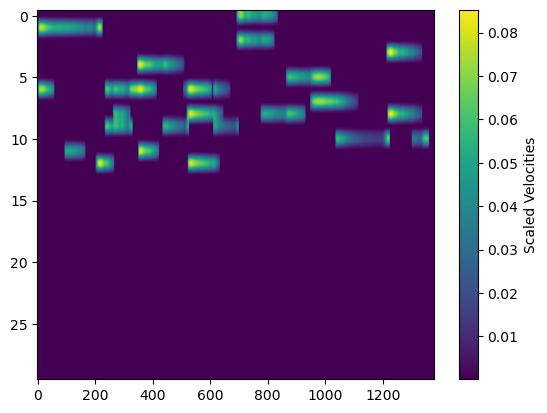

In [27]:

plt.imshow(pitch_amplitudes.detach().cpu().numpy(), aspect='auto')
plt.colorbar( label='Scaled Velocities')


# Audio Features Visual

In [71]:
from gtt.utilities.utils import spec_plot
from matplotlib import pyplot as plt
import librosa

In [72]:
gs_dir = 'Data/GuitarSet/audio_pickup'

split = train_test_split(gs_dir, train_pct=.8, valid_pct=.1)
train_files = split['train']
test_files = split['test']

loudness_metrics_gs = get_mean_std_loudness(gs_dir, train_files)

gs_hrg_test_ds = GttDataset(audio_dir = gs_dir,
                             midi_dir = '',
                             file_list = test_files, 
                             segment_length_seconds=4,
                             max_n_pitch=30,
                             random_crop=False,
                             loud_mean = loudness_metrics_gs['mean'],
                             loud_std = loudness_metrics_gs['std'],
                             full_amps = True,
                             device='cpu')

gs_hrg_test_dl= DataLoader(gs_hrg_test_ds, 3, shuffle=False)

gs_hrg_model = GttNet(device=device,
                      input_length_seconds=4,
                      hop_length=128,
                      harmonic_n_controls=101,
                      gru_features=512,
                      noise_initial_bias=-5.0,
                      mlp_blocks=3,
                      timbre_enc_size = 15,
                      use_timbre_encoder=True,
                      use_amp_latent=False,
                      gru_cat=False,
                      use_reverb=False).to(device)


#load model
ckpt_path = 'model_checkpoints/guitarset_hrg/model_epoch_fa.pt'

gs_hrg_model.load_state_dict(torch.load(ckpt_path))

gs_hrg_model = gs_hrg_model.eval()

In [79]:
for batch in gs_hrg_test_dl:
    in_audio = batch['audio'][1,...].cpu()
    
    loudness = batch['loudness'][1,...].cpu().numpy()
    
    pitch_ampitudes = batch['full_amps'][1,...]
    
    out_audio = gs_hrg_model(batch)[1,...].detach().cpu()
    if i == 2:
        break


torchaudio.save('figure_1_in.wav', in_audio.unsqueeze(0), 22050)
torchaudio.save('figure_1_out_reconstruct.wav', out_audio.unsqueeze(0), 22050)

        
in_audio = in_audio.numpy()
out_audio = out_audio.numpy()

ipd.display(ipd.Audio(in_audio, rate =22050))
ipd.display(ipd.Audio(out_audio, rate =22050))

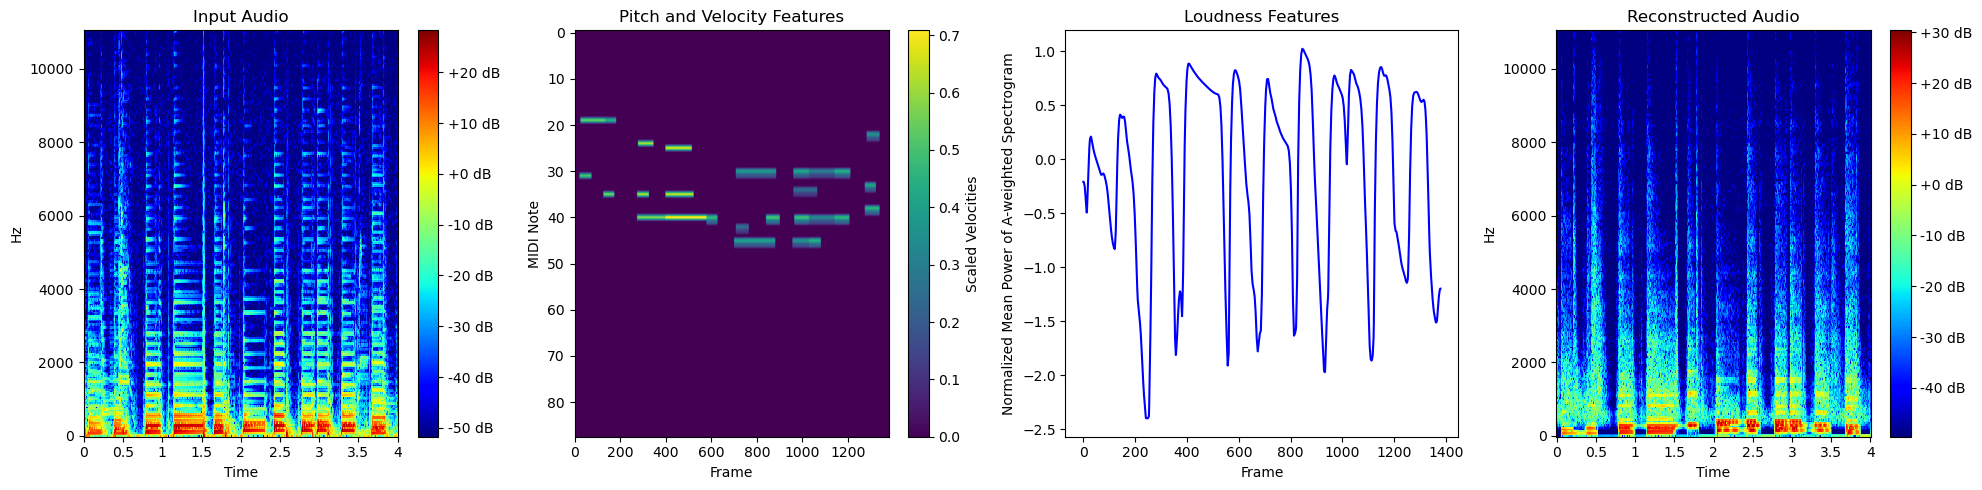

In [80]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

#input audio spect

X = librosa.stft(in_audio, n_fft=512, hop_length=128)
S = librosa.amplitude_to_db(abs(X)) 

v1 = librosa.display.specshow(S, sr=22050, hop_length=128, x_axis='time', y_axis='linear', cmap='jet', ax = axes[0])
fig.colorbar(v1, format='%+2.0f dB', ax= axes[0])
axes[0].set_title('Input Audio')

#Pitch features
v2 = axes[1].imshow(pitch_ampitudes, aspect='auto')
axes[1].set_title('Pitch and Velocity Features')
fig.colorbar(v2, ax=axes[1], label='Scaled Velocities')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('MIDI Note')


#loudness Features
frames = np.arange(loudness.shape[1])
axes[2].plot(frames, loudness[0,:], color='blue')
axes[2].set_title('Loudness Features')
axes[2].set_xlabel('Frame')
axes[2].set_ylabel('Normalized Mean Power of A-weighted Spectrogram')

#output audio spect
X = librosa.stft(out_audio, n_fft=512, hop_length=128)
S = librosa.amplitude_to_db(abs(X))
v3 = librosa.display.specshow(S, sr=22050, hop_length=128, x_axis='time', y_axis='linear', cmap='jet', ax=axes[3])
axes[3].set_title('Reconstructed Audio')
fig.colorbar(v3, ax=axes[3], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('feature_figure.png', dpi=300)
plt.show()